In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
import qutip as qt
from IPython.display import display, Math, Latex

# 设置全局字体为 Times New Roman
%config InlineBackend.figure_format = 'retina'
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({"font.size": 18})

# 启用 LaTeX 渲染
plt.rcParams["text.usetex"] = True

# files = sorted(glob.glob("error_*.txt"))
#  N=2 偏离直线太多了
initial = "000"
N = 6
gamma = 0.1

def caculate_coefficient(r_list):
    if r_list[-1] == 2:  # [1,2]
        b_list = np.array([1 / 3, -4 / 3])
    elif r_list[-1] == 4 or r_list[-1] == 8:  # [1,2,4]
        b_list = np.array([1 / 45, -4 / 9, 64 / 45])
    elif r_list[-1] == 6:  # [1,2,6]
        b_list = np.array([1 / 105, -1 / 6, 81 / 70])
    elif r_list[-1] == 7:  # [1,2,3,7]
        b_list = np.array([-1 / 1152, 64 / 675, -729 / 1600, 117649 / 86400])
    return b_list

N_list = np.array([2, 3, 4, 5, 6])

r1_list = np.array([1, 2, 3, 7])
r2_list = np.array([1, 2, 4])
r3_list = np.array([1, 2, 6])

# coefficients for extrapolation
b1_list = caculate_coefficient(r1_list)
b2_list = caculate_coefficient(r2_list)
b3_list = caculate_coefficient(r3_list)

si_z = [
    qt.tensor([qt.qeye(2)] * i + [qt.sigmaz()] + [qt.qeye(2)] * (N - i - 1))
    for i in range(N)
]

O = sum([si_z[i] for i in range(N)]).full()
O1_list = []
O2_list = []
O3_list = []

step = 100000

rho_superexact = np.load(
    f"../data_sigmap/|{initial}>initial/gamma_{gamma}/rho_superexact_N_{N}_no_Euler.npy"
)
O_superexact = np.real(np.trace(O @ rho_superexact))
    
for r in r1_list:
    rho_Trotter = np.load(f"../data_sigmap/|{initial}>initial/gamma_{gamma}/rho_N_{N}_r_{r}_no_Euler.npy")
    O1_list.append(np.trace(O @ rho_Trotter))

for r in r2_list:
    rho_Trotter = np.load(f"../data_sigmap/|{initial}>initial/gamma_{gamma}/rho_N_{N}_r_{r}_no_Euler.npy")
    O2_list.append(np.trace(O @ rho_Trotter))

for r in r3_list:
    rho_Trotter = np.load(f"../data_sigmap/|{initial}>initial/gamma_{gamma}/rho_N_{N}_r_{r}_no_Euler.npy")
    O3_list.append(np.trace(O @ rho_Trotter))

extrapolated_O1 = sum(b * O for b, O in zip(b1_list, O1_list))
extrapolated_O2 = sum(b * O for b, O in zip(b2_list, O2_list))
extrapolated_O3 = sum(b * O for b, O in zip(b3_list, O3_list))

print(extrapolated_O1)
print(extrapolated_O2)
print(extrapolated_O3)

(5.8862079238450224+1.5207847496703392e-16j)
(5.886207821331528+1.9863587398924723e-16j)
(5.886207877953116+1.755556064479776e-16j)


In [11]:
np.abs(O1_list - O_superexact)

array([0.00884662, 0.00222877, 0.00099188, 0.00018234])

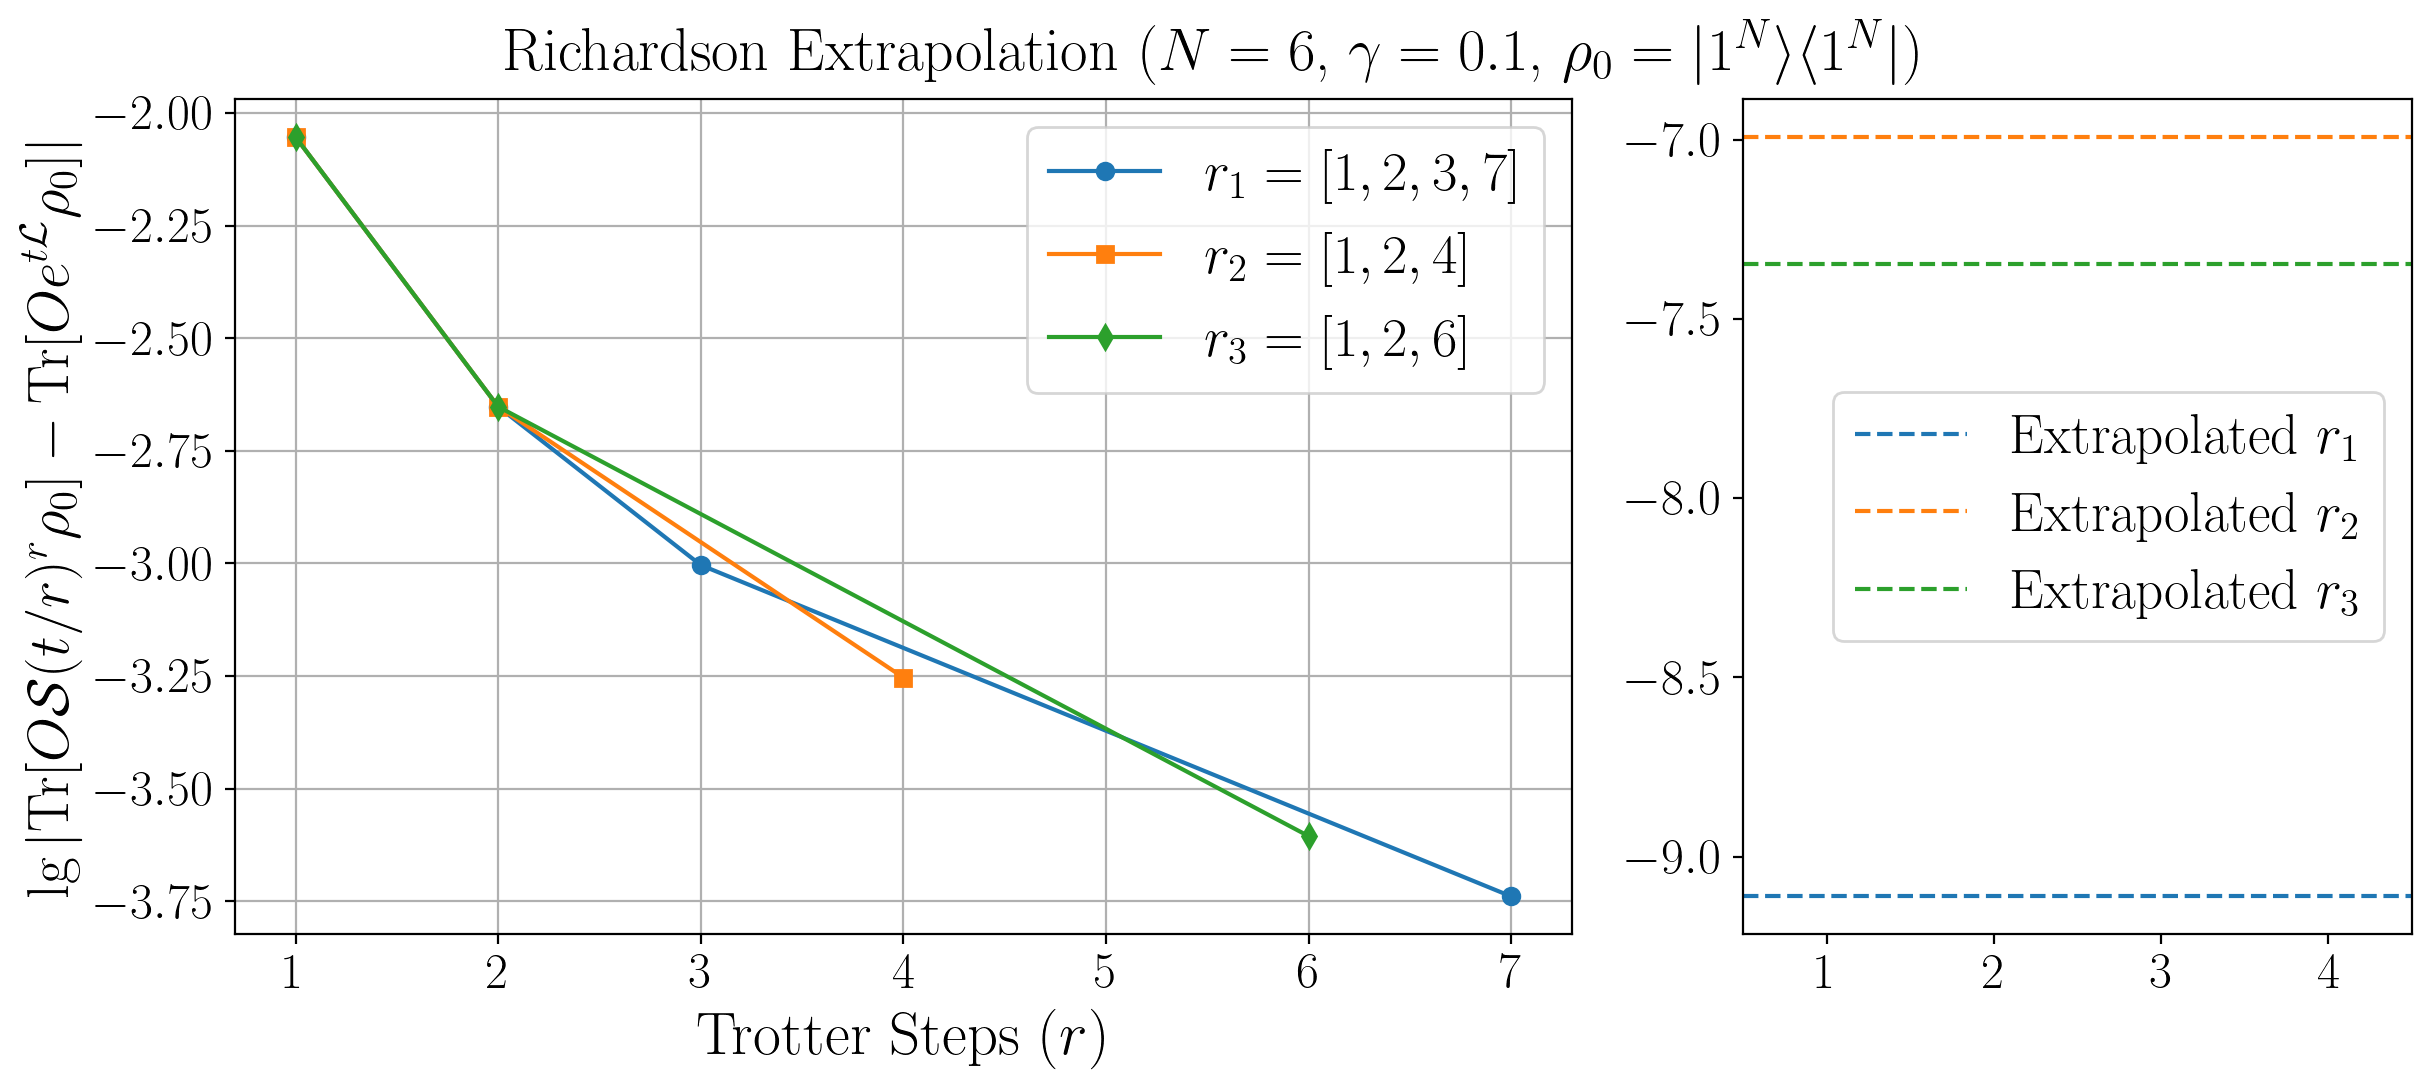

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12.5, 6), gridspec_kw={"width_ratios": [2, 1]})
axs[0].plot(r1_list, np.log(np.abs(O1_list - O_superexact)) / np.log(10), "o-", label="$r_1=[1,2,3,7]$")  # f"$r={r1_list}$")
axs[0].plot(r2_list, np.log(np.abs(O2_list - O_superexact)) / np.log(10), "s-", label="$r_2=[1,2,4]$")  # f"$r={r2_list}$")
axs[0].plot(r3_list, np.log(np.abs(O3_list - O_superexact)) / np.log(10), "d-", label="$r_3=[1,2,6]$")  # f"$r={r3_list}$")


axs[1].axhline(y=np.log(np.abs(extrapolated_O1 - O_superexact)) / np.log(10), color="C0", linestyle="--", label="Extrapolated $r_1$")
axs[1].axhline(y=np.log(np.abs(extrapolated_O2 - O_superexact)) / np.log(10), color="C1", linestyle="--", label="Extrapolated $r_2$")
axs[1].axhline(y=np.log(np.abs(extrapolated_O3 - O_superexact)) / np.log(10), color="C2", linestyle="--", label="Extrapolated $r_3$")


fig.suptitle(
    f"Richardson Extrapolation ($N={N}$, $\\gamma={gamma}$, $\\rho_0 = |1^N\\rangle \langle 1^N|$)",
    y=0.92,
)
# , fontsize=22)
# fig.supxlabel("Trotter Steps ($r$)", y=0.08)

axs[0].set(
    # xlabel="Trotter Steps ($r$)",
    # ylabel="Observable Average Error (log scale)",
    xticks=range(1, 8),
)
axs[0].set_xlabel("Trotter Steps ($r$)", fontsize=22)
# axs[0].set_ylabel("Observable Error (log scale)", fontsize=21)
axs[0].set_ylabel(
    "$\lg|\mathrm{Tr}[O\mathcal{S}(t/r)^r\\rho_0]-\mathrm{Tr}[Oe^{t\mathcal{L}}\\rho_0]|$",
    fontsize=21,
)
axs[0].legend(loc="best", fontsize=20)
# axs[0].set_yticks([-3.5, -3, -2.5, -2, -1.5])

axs[1].legend(loc="best", fontsize=20)
# axs[1].set_ylim(-11.45,-10.95)
# axs[1].set_yticks([-11.4, -11.3, -11.2,-11.1, -11.0])
axs[1].set_xlim(0.5, 4.5)
axs[1].set_xticks([1, 2, 3, 4])

axs[0].grid()
# axs[1].grid()
fig.tight_layout()
plt.savefig(f"extrapolation-{N}-{initial}_sigmap.pdf")
plt.show()